In [2]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached numpy-2.4.2-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pillow-12.1.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-macosx_10_13_universal2.whl (2.8 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached numpy-

In [8]:
pip install weather-model-graphs

  Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 3.6 MB/s  0:00:01 eta 0:00:01
Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl (20.3 MB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [weather-model-graphs]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
import networkx as nx

import weather_model_graphs as wmg
from weather_model_graphs.visualise import nx_draw_with_pos_and_attr

xy_mesh = np.array([
    [0.1, 0.1], [0.1, 0.2], [0.2, 0.1], [0.2, 0.2]
])
xy_grid = np.array([
    [0.15, 0.15],
    [0.70, 0.70],
])


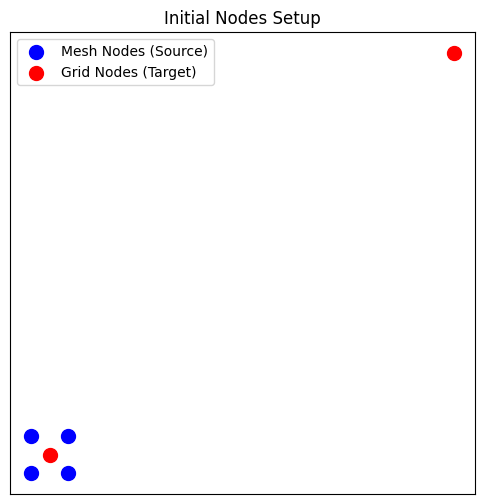

In [ ]:
G_source = wmg.create.mesh.create_single_level_2d_mesh_graph(xy=xy_mesh, nx=2, ny=2)
G_target = wmg.create.grid.create_grid_graph_nodes(xy=xy_grid)

fig, ax = plt.subplots(figsize=(6, 6))
pos_source = {node: G_source.nodes[node]["pos"] for node in G_source.nodes()}
pos_target = {node: G_target.nodes[node]["pos"] for node in G_target.nodes()}

nx.draw_networkx_nodes(G_source, pos=pos_source, ax=ax, node_color='blue', node_size=100, label='Mesh Nodes (Source)')
nx.draw_networkx_nodes(G_target, pos=pos_target, ax=ax, node_color='red', node_size=100, label='Grid Nodes (Target)')
ax.legend()
plt.title('Initial Nodes Setup')
plt.show()


In [ ]:
# We expect a warning triggered here because the far grid node is isolated.
G_connect = wmg.create.base.connect_nodes_across_graphs(
    G_source=G_source,
    G_target=G_target,
    method="within_radius",
    max_dist=0.3,
)


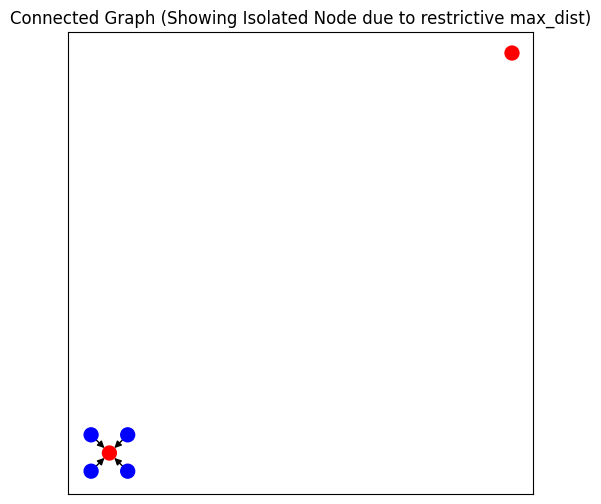

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
nx.draw_networkx(G_connect, pos={n: G_connect.nodes[n]['pos'] for n in G_connect.nodes}, 
                 ax=ax, with_labels=False, node_size=100, 
                 node_color=['blue' if n in G_source else 'red' for n in G_connect.nodes()])
plt.title('Connected Graph (Showing Isolated Node due to restrictive max_dist)')
plt.show()
